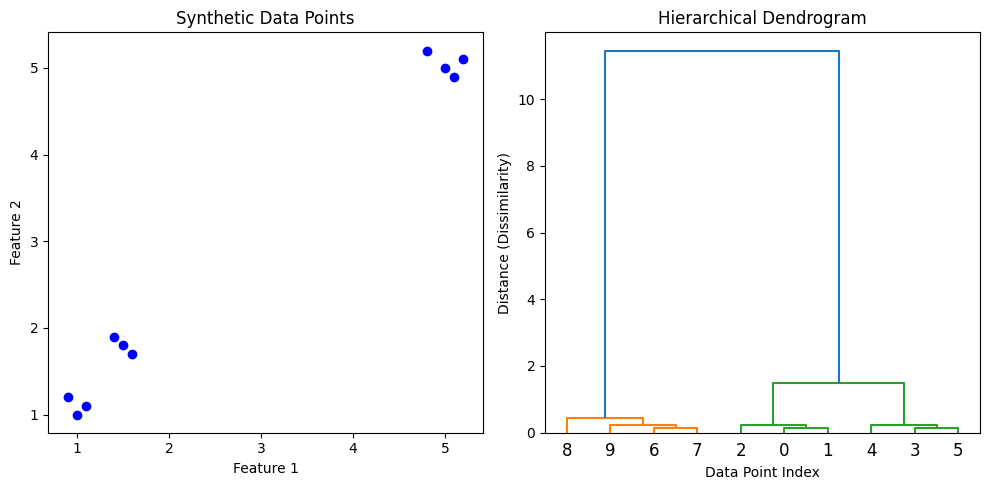

In [1]:
# first we try to understand with a small synthetic example
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Create Synthetic Data (3 nested clusters)
# Group A (bottom left), Group B (slightly above A), Group C (top right)
X = np.array([
    [1, 1], [1.1, 1.1], [0.9, 1.2],    # Group A
    [1.5, 1.8], [1.6, 1.7], [1.4, 1.9], # Group B (Near A)
    [5, 5], [5.1, 4.9], [4.8, 5.2], [5.2, 5.1] # Group C (Far)
])

# Perform Hierarchical Clustering
# 'ward' linkage minimizes the variance of clusters being merged
Z = linkage(X, method='ward')

# Plotting
plt.figure(figsize=(10, 5))

# Plot 1: The Scatter Plot (What the data looks like)
plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:,1], c='blue')
plt.title("Synthetic Data Points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# Plot 2: The Dendrogram (The 'Tree')
plt.subplot(1, 2, 2)
dendrogram(Z)
plt.title("Hierarchical Dendrogram")
plt.xlabel("Data Point Index")
plt.ylabel("Distance (Dissimilarity)")

plt.tight_layout()
plt.show()

In [2]:
# THIS time we will put it into tree
from scipy.cluster.hierarchy import to_tree
import pandas as pd

# Convert the matrix into a tree object and a list of all nodes
rootnode, nodelist = to_tree(Z, rd=True)

# blank map
parent_map = {node.id: None for node in nodelist}

# Populate the map by traversing the nodes
for node in nodelist:
    if not node.is_leaf():
        # The current node is the parent of its left and right children
        parent_map[node.left.id] = node.id
        parent_map[node.right.id] = node.id

# Create the final flat structure for your database
hierarchy_data = []
for node in nodelist:
    hierarchy_data.append({
        "node_id": node.id,
        "parent_id": parent_map[node.id],  # Now populated
        "is_leaf": node.is_leaf(),
        "distance": node.dist if not node.is_leaf() else 0,
        "count": node.count # Number of original points in this cluster
    })

# Convert to DataFrame
df_hierarchy = pd.DataFrame(hierarchy_data)

# show it
df_hierarchy.describe()
df_hierarchy.info()
df_hierarchy.head(25)


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   node_id    19 non-null     int64  
 1   parent_id  18 non-null     float64
 2   is_leaf    19 non-null     bool   
 3   distance   19 non-null     float64
 4   count      19 non-null     int64  
dtypes: bool(1), float64(2), int64(2)
memory usage: 759.0 bytes


,node_id,parent_id,is_leaf,distance,count
0,0,12.0,True,0.000000,1
1,1,12.0,True,0.000000,1
2,2,14.0,True,0.000000,1
3,3,11.0,True,0.000000,1
4,4,15.0,True,0.000000,1
5,5,11.0,True,0.000000,1
6,6,10.0,True,0.000000,1
7,7,10.0,True,0.000000,1
8,8,16.0,True,0.000000,1
9,9,13.0,True,0.000000,1


In [3]:
# THIS time we will apply on some real data
Spellman_df = pd.read_csv('../data/clustering/Spellman.csv')

Spellman_df.describe()
Spellman_df.info()
Spellman_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 4381 entries, 0 to 4380
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    4381 non-null   str    
 1   40      4381 non-null   float64
 2   50      4381 non-null   float64
 3   60      4381 non-null   float64
 4   70      4381 non-null   float64
 5   80      4381 non-null   float64
 6   90      4381 non-null   float64
 7   100     4381 non-null   float64
 8   110     4381 non-null   float64
 9   120     4381 non-null   float64
 10  130     4381 non-null   float64
 11  140     4381 non-null   float64
 12  150     4381 non-null   float64
 13  160     4381 non-null   float64
 14  170     4381 non-null   float64
 15  180     4381 non-null   float64
 16  190     4381 non-null   float64
 17  200     4381 non-null   float64
 18  210     4381 non-null   float64
 19  220     4381 non-null   float64
 20  230     4381 non-null   float64
 21  240     4381 non-null   float64
 22  250     438

,time,40,50,60,70,80,90,100,110,120,...,170,180,190,200,210,220,230,240,250,260
0,YAL001C,-0.070,-0.23,-0.100,0.03,-0.04,-0.12,-0.28,-0.44,-0.09,...,0.59,0.34,-0.28,-0.09,-0.44,0.31,0.03,0.57,0.00,0.010
1,YAL014C,0.215,0.09,0.025,-0.04,-0.04,-0.02,-0.51,-0.08,0.00,...,-0.30,-0.38,0.07,-0.04,0.13,-0.06,-0.26,-0.10,0.27,0.235
2,YAL016W,0.150,0.15,0.220,0.29,-0.10,0.15,-0.73,0.19,-0.15,...,0.12,-0.17,0.11,-0.15,0.03,-0.26,-0.34,-0.34,0.25,0.190
3,YAL020C,-0.350,-0.28,-0.215,-0.15,0.16,-0.12,0.26,0.00,0.13,...,0.07,0.61,-0.20,0.49,-0.43,0.80,-0.47,1.01,-0.36,-0.405
4,YAL022C,-0.415,-0.59,-0.580,-0.57,-0.09,-0.34,0.49,0.32,1.15,...,-0.48,-0.40,-0.59,0.54,-0.09,1.03,0.08,0.57,-0.26,-0.310


In [4]:
# drop first text column
cleaned_Spellman_df = Spellman_df.drop(['time'], axis = 1)

cleaned_Spellman_df.describe()
cleaned_Spellman_df.info()
cleaned_Spellman_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 4381 entries, 0 to 4380
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   40      4381 non-null   float64
 1   50      4381 non-null   float64
 2   60      4381 non-null   float64
 3   70      4381 non-null   float64
 4   80      4381 non-null   float64
 5   90      4381 non-null   float64
 6   100     4381 non-null   float64
 7   110     4381 non-null   float64
 8   120     4381 non-null   float64
 9   130     4381 non-null   float64
 10  140     4381 non-null   float64
 11  150     4381 non-null   float64
 12  160     4381 non-null   float64
 13  170     4381 non-null   float64
 14  180     4381 non-null   float64
 15  190     4381 non-null   float64
 16  200     4381 non-null   float64
 17  210     4381 non-null   float64
 18  220     4381 non-null   float64
 19  230     4381 non-null   float64
 20  240     4381 non-null   float64
 21  250     4381 non-null   float64
 22  260     438

,40,50,60,70,80,90,100,110,120,130,...,170,180,190,200,210,220,230,240,250,260
0,-0.070,-0.23,-0.100,0.03,-0.04,-0.12,-0.28,-0.44,-0.09,0.12,...,0.59,0.34,-0.28,-0.09,-0.44,0.31,0.03,0.57,0.00,0.010
1,0.215,0.09,0.025,-0.04,-0.04,-0.02,-0.51,-0.08,0.00,0.46,...,-0.30,-0.38,0.07,-0.04,0.13,-0.06,-0.26,-0.10,0.27,0.235
2,0.150,0.15,0.220,0.29,-0.10,0.15,-0.73,0.19,-0.15,0.29,...,0.12,-0.17,0.11,-0.15,0.03,-0.26,-0.34,-0.34,0.25,0.190
3,-0.350,-0.28,-0.215,-0.15,0.16,-0.12,0.26,0.00,0.13,-0.20,...,0.07,0.61,-0.20,0.49,-0.43,0.80,-0.47,1.01,-0.36,-0.405
4,-0.415,-0.59,-0.580,-0.57,-0.09,-0.34,0.49,0.32,1.15,0.20,...,-0.48,-0.40,-0.59,0.54,-0.09,1.03,0.08,0.57,-0.26,-0.310


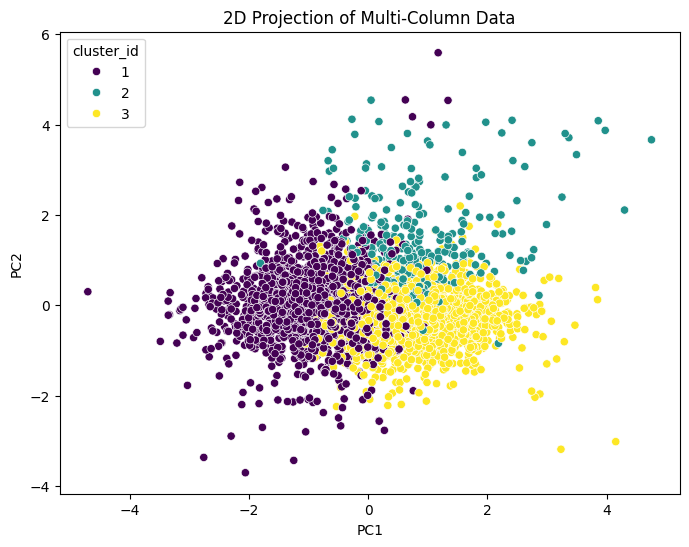

In [5]:
# Plotting, THIS time we will go with some different techniques to handle around 5K data

from sklearn.decomposition import PCA
import seaborn as sns

# Perform Hierarchical Clustering
# 'ward' linkage minimizes the variance of clusters being merged
Z = linkage(cleaned_Spellman_df, method='ward')

# Reduce dimensions to 2
pca = PCA(n_components=2)
components = pca.fit_transform(cleaned_Spellman_df) # Use the 1/0 numeric data

# dataframe for scatter plot
# Add PC1 and PC2 to your dataframe
scatter_plot_df = pd.DataFrame({
   'PC1' : components[:, 0],
   'PC2' : components[:, 1]
   })

# df_raw['PC1'] = components[:, 0]
# df_raw['PC2'] = components[:, 1]

# Plot the clusters found by the hierarchy (using a 'cut' at k=3)
from scipy.cluster.hierarchy import fcluster
scatter_plot_df['cluster_id'] = fcluster(Z, t=3, criterion='maxclust')

plt.figure(figsize=(8,6))
sns.scatterplot(data=scatter_plot_df, x='PC1', y='PC2', hue='cluster_id', palette='viridis')
plt.title("2D Projection of Multi-Column Data")
plt.show()

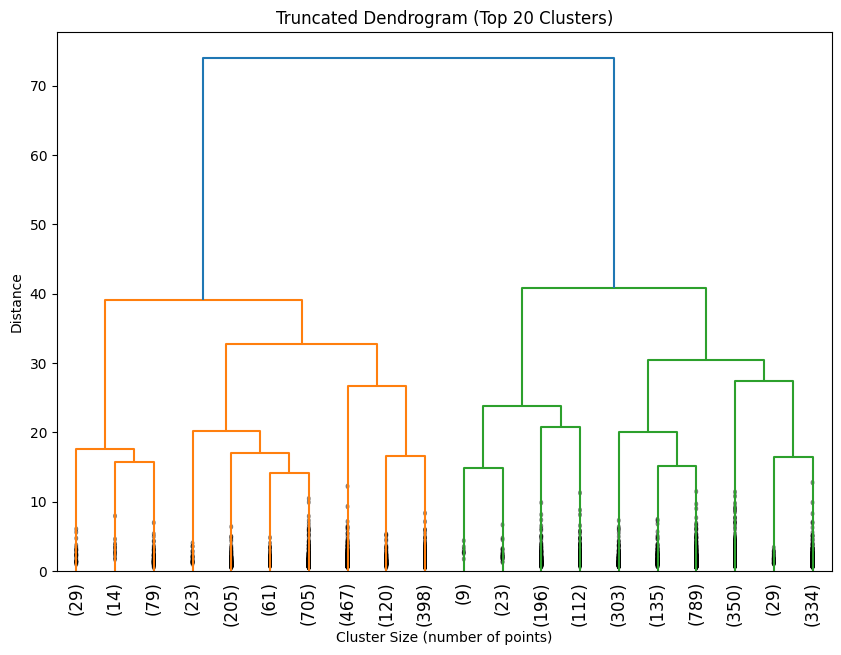

In [6]:
# dendrogram for 5K data
from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(10, 7))
dendrogram(
    Z,
    truncate_mode='lastp',  # Show only the last 'p' merged clusters
    p=20,                   # Show only the top 20 nodes
    show_leaf_counts=True,  # Show how many points are in each leaf
    leaf_rotation=90.,
    leaf_font_size=12.,
    show_contracted=True,   # Draw black dots at the heights of those hidden merges
)
plt.title("Truncated Dendrogram (Top 20 Clusters)")
plt.xlabel("Cluster Size (number of points)")
plt.ylabel("Distance")
plt.show()

In [7]:
# FRUAD transaction details
fraud_transactions_df = pd.read_csv('../data/clustering/Fraud Detection Transactions Dataset.csv')

fraud_transactions_df.describe()
fraud_transactions_df.info()
fraud_transactions_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                50000 non-null  str    
 1   User_ID                       50000 non-null  str    
 2   Transaction_Amount            50000 non-null  float64
 3   Transaction_Type              50000 non-null  str    
 4   Timestamp                     50000 non-null  str    
 5   Account_Balance               50000 non-null  float64
 6   Device_Type                   50000 non-null  str    
 7   Location                      50000 non-null  str    
 8   Merchant_Category             50000 non-null  str    
 9   IP_Address_Flag               50000 non-null  int64  
 10  Previous_Fraudulent_Activity  50000 non-null  int64  
 11  Daily_Transaction_Count       50000 non-null  int64  
 12  Avg_Transaction_Amount_7d     50000 non-null  float64
 13  Failed_Trans

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,...,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend,Fraud_Label
0,TXN_33553,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,...,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0,0
1,TXN_9427,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,...,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0,1
2,TXN_199,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,...,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0,1
3,TXN_12447,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,...,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0,1
4,TXN_39489,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,...,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1,1


In [8]:
# it's labelled data, so we will first drop label column and then try to cluster
# TODO later on we can explore with supervised classification algorithm

cleaned_fraud_transactions_df = fraud_transactions_df.drop(['Transaction_ID', 'Fraud_Label'], axis = 1)

cleaned_fraud_transactions_df.describe()
cleaned_fraud_transactions_df.info()
cleaned_fraud_transactions_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   User_ID                       50000 non-null  str    
 1   Transaction_Amount            50000 non-null  float64
 2   Transaction_Type              50000 non-null  str    
 3   Timestamp                     50000 non-null  str    
 4   Account_Balance               50000 non-null  float64
 5   Device_Type                   50000 non-null  str    
 6   Location                      50000 non-null  str    
 7   Merchant_Category             50000 non-null  str    
 8   IP_Address_Flag               50000 non-null  int64  
 9   Previous_Fraudulent_Activity  50000 non-null  int64  
 10  Daily_Transaction_Count       50000 non-null  int64  
 11  Avg_Transaction_Amount_7d     50000 non-null  float64
 12  Failed_Transaction_Count_7d   50000 non-null  int64  
 13  Card_Type   

,User_ID,Transaction_Amount,Transaction_Type,Timestamp,Account_Balance,Device_Type,Location,Merchant_Category,IP_Address_Flag,Previous_Fraudulent_Activity,Daily_Transaction_Count,Avg_Transaction_Amount_7d,Failed_Transaction_Count_7d,Card_Type,Card_Age,Transaction_Distance,Authentication_Method,Risk_Score,Is_Weekend
0,USER_1834,39.79,POS,2023-08-14 19:30:00,93213.17,Laptop,Sydney,Travel,0,0,7,437.63,3,Amex,65,883.17,Biometric,0.8494,0
1,USER_7875,1.19,Bank Transfer,2023-06-07 04:01:00,75725.25,Mobile,New York,Clothing,0,0,13,478.76,4,Mastercard,186,2203.36,Password,0.0959,0
2,USER_2734,28.96,Online,2023-06-20 15:25:00,1588.96,Tablet,Mumbai,Restaurants,0,0,14,50.01,4,Visa,226,1909.29,Biometric,0.8400,0
3,USER_2617,254.32,ATM Withdrawal,2023-12-07 00:31:00,76807.20,Tablet,New York,Clothing,0,0,8,182.48,4,Visa,76,1311.86,OTP,0.7935,0
4,USER_2014,31.28,POS,2023-11-11 23:44:00,92354.66,Mobile,Mumbai,Electronics,0,1,14,328.69,4,Mastercard,140,966.98,Password,0.3819,1


In [9]:
# apply DBSCAN on data
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score, davies_bouldin_score

# identify categorical and numerical columns
cat_cols = [col for col in cleaned_fraud_transactions_df.columns if cleaned_fraud_transactions_df[col].dtype == 'str']
num_cols = [col for col in cleaned_fraud_transactions_df.columns if col not in cat_cols]

# Build the Preprocessing Pipeline
# We apply Ordinal Encoding to categories and Scaling to everything
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(), cat_cols),
        ('num', StandardScaler(), num_cols)
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()) # Final scale to ensure all features have equal weight
])

# Process Data and Cluster
X_transformed = pipeline.fit_transform(cleaned_fraud_transactions_df)

# Fit DBSCAN (Note: DBSCAN is often used outside the pipeline for fit_predict)
# These hyperparameters we can optimize later on by some iterative metric evaluation
dbscan = DBSCAN(eps=1.0, min_samples=2)
labels = dbscan.fit_predict(X_transformed)

# Evaluation Metrics
# INTRODUCING safe calculations
# Filter out the noise (-1)
core_labels = labels[labels != -1]
core_samples = X_transformed[labels != -1]

# Count unique clusters (excluding noise)
unique_clusters = len(set(core_labels))

# Safe Evaluation
if unique_clusters > 1:
    sil = silhouette_score(X_transformed[labels != -1], labels[labels != -1])
    dbi = davies_bouldin_score(X_transformed[labels != -1], labels[labels != -1])
    print(f"Silhouette Score: {sil:.3f}")
    print(f"Davies-Bouldin Index: {dbi:.3f}")
else:
    print(f"Evaluation Skipped: Found {unique_clusters} cluster(s).")
    print("Action: Try decreasing 'eps' or decreasing 'min_samples' to split the data.")

Evaluation Skipped: Found 1 cluster(s).
Action: Try decreasing 'eps' or decreasing 'min_samples' to split the data.


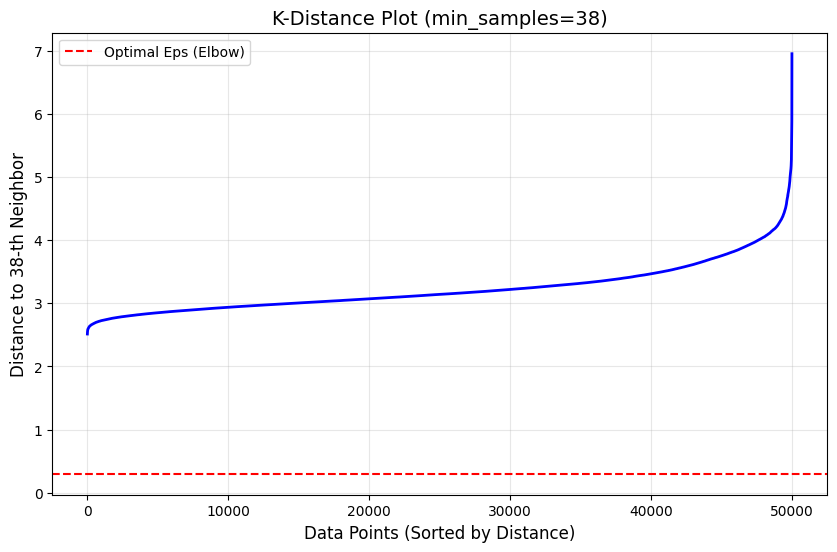

In [10]:
# K-DISTANT plot we will use to find optimal hyperparameters eps and n_samples
from sklearn.neighbors import NearestNeighbors

# SET HYPERPARAMETER: min_samples (k)
# Rule of thumb: k = 2 * number of dimensions
k_neighbors = 2 * X_transformed.shape[1] 

# CALCULATE K-NEAREST NEIGHBORS
# We use the scaled feature matrix 'X_transformed' from earlier
neigh = NearestNeighbors(n_neighbors=k_neighbors)
nbrs = neigh.fit(X_transformed)
distances, indices = nbrs.kneighbors(X_transformed)

# SORT DISTANCES
# We take the distance to the k-th neighbor (the last column)
# and sort them from smallest to largest
k_distances = np.sort(distances[:, k_neighbors - 1], axis=0)

# PLOT THE K-DISTANCE GRAPH
plt.figure(figsize=(10, 6))
plt.plot(k_distances, color='blue', lw=2)
plt.title(f'K-Distance Plot (min_samples={k_neighbors})', fontsize=14)
plt.xlabel('Data Points (Sorted by Distance)', fontsize=12)
plt.ylabel(f'Distance to {k_neighbors}-th Neighbor', fontsize=12)

# Visually identify the 'elbow' where the slope sharply increases
# Let's say the elbow is at y=0.3 for this example
plt.axhline(y=0.3, color='red', linestyle='--', label='Optimal Eps (Elbow)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# WE HE GOT K = 2 * 19 (dimensions) and eps takes sharp vertical curve at point around eps = 4
# NOW we will check for manual eps adjustment

# Range of potential eps values to test (based on your K-distance plot 1.0 to 5.0)
eps_values = np.arange(1.0, 4.5, 0.5) 
min_samples = 2 * X_transformed.shape[1]

for e in eps_values:
    db = DBSCAN(eps=e, min_samples=min_samples).fit(X_transformed)
    labels = db.labels_
    
    # Only evaluate if we have more than 1 cluster (excluding noise)
    mask = labels != -1
    if len(np.unique(labels[mask])) > 1:
        sil = silhouette_score(X_transformed[labels != -1], labels[labels != -1])
        dbi = davies_bouldin_score(X_transformed[labels != -1], labels[labels != -1])
        print(f"Eps: {e:.1f} | Silhouette Score: {sil:.3f} | Davies-Bouldin Index: {dbi:.3f}")
    else:
        print(f"Eps: {e:.1f} | Not enough clusters to evaluate.")

Eps: 1.0 | Not enough clusters to evaluate.
Eps: 1.5 | Not enough clusters to evaluate.
Eps: 2.0 | Not enough clusters to evaluate.
Eps: 2.5 | Not enough clusters to evaluate.
Eps: 3.0 | Not enough clusters to evaluate.
Eps: 3.5 | Silhouette Score: 0.130 | Davies-Bouldin Index: 2.457
Eps: 4.0 | Silhouette Score: 0.206 | Davies-Bouldin Index: 1.799


In [12]:
# THIS time we will focus on PCA before dunning DBscan
from sklearn.decomposition import PCA

# Scale first (PCA and DBSCAN require this!)
# already StandardScaler data will have no impact again, harmless
X_scaled = StandardScaler().fit_transform(X_transformed)

# 2. Reduce 19 dimensions to 5 (keeping most of the 'meaning')
pca = PCA(n_components=5) 
X_pca = pca.fit_transform(X_scaled)

print(f"Variance explained by 5 components: {sum(pca.explained_variance_ratio_):.2%}")

# New 'min_samples' based on 5 dimensions
new_min_samples = 2 * X_pca.shape[1]

# Run DBSCAN on the reduced data
db = DBSCAN(eps=1.5, min_samples=new_min_samples).fit(X_pca)

labels = dbscan.fit_predict(X_pca)

# Evaluation Metrics
# INTRODUCING safe calculations
# Filter out the noise (-1)
core_labels = labels[labels != -1]
core_samples = X_pca[labels != -1]

# Count unique clusters (excluding noise)
unique_clusters = len(set(core_labels))

# Safe Evaluation
if unique_clusters > 1:
    sil = silhouette_score(X_pca[labels != -1], labels[labels != -1])
    dbi = davies_bouldin_score(X_pca[labels != -1], labels[labels != -1])
    print(f"Silhouette Score: {sil:.3f}")
    print(f"Davies-Bouldin Index: {dbi:.3f}")
else:
    print(f"Evaluation Skipped: Found {unique_clusters} cluster(s).")
    print("Action: Try decreasing 'eps' or decreasing 'min_samples' to split the data.")

Variance explained by 5 components: 27.01%
Silhouette Score: 0.085
Davies-Bouldin Index: 0.640


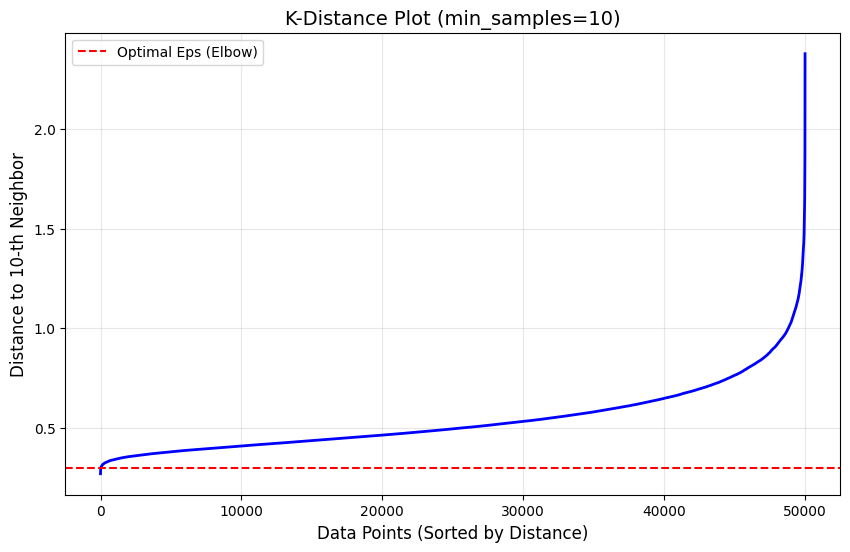

In [13]:
# K-DISTANT plot we will use to find optimal hyperparameters eps and n_samples

# SET HYPERPARAMETER: min_samples (k)
# Rule of thumb: k = 2 * number of dimensions
k_neighbors = 2 * X_pca.shape[1] 

# CALCULATE K-NEAREST NEIGHBORS
# We use the scaled feature matrix 'X_pca' from earlier
neigh = NearestNeighbors(n_neighbors=k_neighbors)
nbrs = neigh.fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)

# SORT DISTANCES
# We take the distance to the k-th neighbor (the last column)
# and sort them from smallest to largest
k_distances = np.sort(distances[:, k_neighbors - 1], axis=0)

# PLOT THE K-DISTANCE GRAPH
plt.figure(figsize=(10, 6))
plt.plot(k_distances, color='blue', lw=2)
plt.title(f'K-Distance Plot (min_samples={k_neighbors})', fontsize=14)
plt.xlabel('Data Points (Sorted by Distance)', fontsize=12)
plt.ylabel(f'Distance to {k_neighbors}-th Neighbor', fontsize=12)

# Visually identify the 'elbow' where the slope sharply increases
# Let's say the elbow is at y=0.3 for this example
plt.axhline(y=0.3, color='red', linestyle='--', label='Optimal Eps (Elbow)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# NOW we will run HDBscan on PCA data
from sklearn.cluster import HDBSCAN

# RUN HDBSCAN
# min_cluster_size: The minimum size you want your groups to be.
# min_samples: Controls how 'conservative' the clustering is (defaults to min_cluster_size).
clusterer = HDBSCAN(min_cluster_size=50, min_samples=new_min_samples)
labels = clusterer.fit_predict(X_pca)

# EVALUATION (Excluding Noise -1)
mask = labels != -1
if len(np.unique(labels[mask])) > 1:
    sil = silhouette_score(X_pca[mask], labels[mask])
    dbi = davies_bouldin_score(X_pca[mask], labels[mask])
    
    print(f"Clusters found: {len(np.unique(labels[mask]))}")
    print(f"Silhouette Score: {sil:.3f}")
    print(f"Davies-Bouldin Index: {dbi:.3f}")
    print(f"Fraud/Noise detected: {np.sum(labels == -1)} transactions")

C:\python\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


Clusters found: 2
Silhouette Score: 0.113
Davies-Bouldin Index: 2.267
Fraud/Noise detected: 49756 transactions
